## Part 0: Data Loading & Joins (2 pts)

#### 0.1 --> Load the three Census tables


In [27]:
import pandas as pd

#Viviendas
vivienda_cols = [
    'id_vivienda', 
    'region', 
    'comuna',               
    'p4a_mat_paredes',      
    'p4b_mat_techo',        
    'p4c_mat_piso',         
    'indice_hacinamiento'   
]
viv = pd.read_parquet('../Datos/viviendas_censo2024.parquet', columns=vivienda_cols)
print(" Viviendas cargadas con éxito!")

#Hogares
hogar_cols = ['id_vivienda', 'id_hogar', 'p12_tenencia_viv'] 
hog = pd.read_parquet('../Datos/hogares_censo2024.parquet', columns=hogar_cols)
hog = hog.rename(columns={'p12_tenencia_viv': 'tenencia'})
print(" Hogares cargados con éxito!")

#Personas
persona_cols = [
    'id_vivienda', 'id_hogar', 'id_persona', 'sexo', 'edad', 
    'p27_nacionalidad', 'p27_nacionalidad_rec', 'p24_lug_resid5', 
    'p25_lug_nacimiento', 'p25_lug_nacimiento_rec', 'p26_llegada_periodo', 'escolaridad', 
    'cine11', 'sit_fuerza_trabajo', 'cod_ciuo', 'cod_caenes', 
    'p45_medio_transporte', 'p27_nacionalidad_esp', 'p24_lug_resid5_esp'
]

per = pd.read_parquet('../Datos/personas_censo2024.parquet', columns=persona_cols)
print(" Personas cargadas con éxito!")

 Viviendas cargadas con éxito!
 Hogares cargados con éxito!
 Personas cargadas con éxito!


Se cargan los 3 dataset con los que trabajaremos y además se filtran las columnas a con las que se harán los análisis.

##### como hacinamiento no existe en el dataset de Hogares no lo agregaremos, pero nos dimos cuenta si existe en el dataset de Viviendas, por lo que suponemos que fue un error de parte del profesor.

#### 0.2 --> Filter Comunas

In [28]:
# 13301 = Colina
# 13501 = Melipilla
# 13601 = Talagante

MIS_COMUNAS = [13301, 13501, 13601]

viv = viv[viv["comuna"].isin(MIS_COMUNAS)].copy()
hog = hog[hog["id_vivienda"].isin(viv["id_vivienda"])].copy()
per = per[per["id_vivienda"].isin(viv["id_vivienda"])].copy()

# Renombrar comunas SOLO en los datos filtrados
mapa_comunas = {
    13301: "Colina",
    13501: "Melipilla",
    13601: "Talagante"
}

viv["comuna"] = viv["comuna"].map(mapa_comunas)

print(f"Filas en viv: {len(viv):,} filas")
print(f"Filas en hog: {len(hog):,} filas")
print(f"Filas en per: {len(per):,} filas")

print("\nComunas presentes en viv:")
print(viv["comuna"].value_counts().sort_index())

Filas en viv: 134,838 filas
Filas en hog: 122,147 filas
Filas en per: 386,047 filas

Comunas presentes en viv:
comuna
Colina       54882
Melipilla    52376
Talagante    27580
Name: count, dtype: int64


De todas las comunas disponibles, se filtran Colina, Melipilla y Talagante, que serán las comunas analizadas. Además, nos da la cantidad de filas resultante en cada dataset.

#### 0.3 --> Join the tables

In [29]:
df = per.merge(hog, on=["id_vivienda", "id_hogar"], how="left") \
        .merge(viv, on="id_vivienda", how="left")

assert len(df) == len(per), "Row count mismatch after join!"

print("df.shape:", df.shape)
df.info()

df.shape: (386047, 26)
<class 'pandas.DataFrame'>
RangeIndex: 386047 entries, 0 to 386046
Data columns (total 26 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id_vivienda             386047 non-null  int32  
 1   id_hogar                386047 non-null  int32  
 2   id_persona              386047 non-null  int32  
 3   sexo                    386047 non-null  int32  
 4   edad                    386047 non-null  int32  
 5   p27_nacionalidad        386047 non-null  int32  
 6   p27_nacionalidad_rec    386047 non-null  int32  
 7   p24_lug_resid5          386047 non-null  int32  
 8   p25_lug_nacimiento      386047 non-null  int32  
 9   p25_lug_nacimiento_rec  386047 non-null  int32  
 10  p26_llegada_periodo     38126 non-null   float64
 11  escolaridad             386047 non-null  int32  
 12  cine11                  386047 non-null  int32  
 13  sit_fuerza_trabajo      303949 non-null  float64
 14  cod_ciuo

Se revisa cómo quedó la base final, viendo cuántas filas y columnas tiene, qué variables incluye y si hay datos faltantes en algunas de ellas.

## Part 1: Demographic Profile (3 pts)


#### 1.1 --> Age pyramid by sex (1 pt)
##### La pirámide muestra la población de las comunas analizadas, distribuida por sexo y grupos de edad, diferenciando entre personas nacidas en Chile y nacidas fuera de Chile.


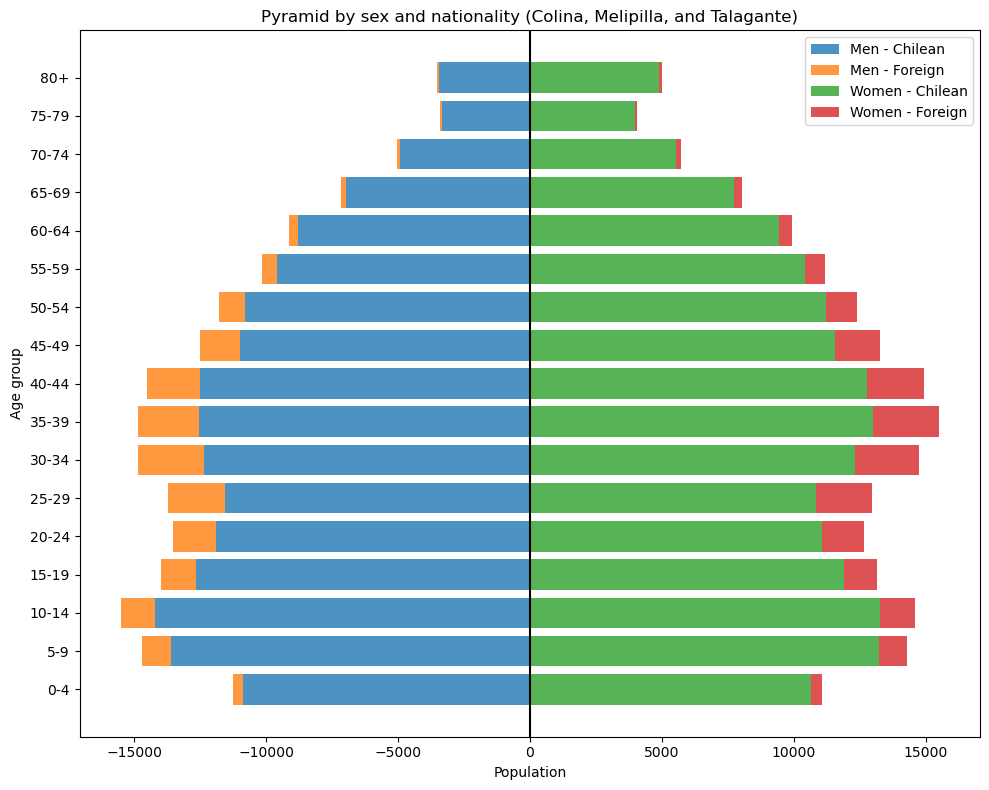

In [30]:
import matplotlib.pyplot as plt

piramide = df[df["edad"] != -99].copy()

bins = list(range(0, 81, 5)) + [200]
labels = [f"{i}-{i+4}" for i in range(0, 80, 5)] + ["80+"]

piramide["age_group"] = pd.cut(
    piramide["edad"],
    bins=bins,
    labels=labels,
    right=False
)

h_ch = piramide[(piramide["sexo"] == 1) & (piramide["p25_lug_nacimiento_rec"] == 1)]["age_group"].value_counts().sort_index()
h_ex = piramide[(piramide["sexo"] == 1) & (piramide["p25_lug_nacimiento_rec"] == 2)]["age_group"].value_counts().sort_index()
m_ch = piramide[(piramide["sexo"] == 2) & (piramide["p25_lug_nacimiento_rec"] == 1)]["age_group"].value_counts().sort_index()
m_ex = piramide[(piramide["sexo"] == 2) & (piramide["p25_lug_nacimiento_rec"] == 2)]["age_group"].value_counts().sort_index()

h_ch = h_ch.reindex(labels, fill_value=0)
h_ex = h_ex.reindex(labels, fill_value=0)
m_ch = m_ch.reindex(labels, fill_value=0)
m_ex = m_ex.reindex(labels, fill_value=0)

plt.figure(figsize=(10, 8))

# Hombres: chilenos pegados al centro, extranjeros hacia afuera
plt.barh(labels, -h_ch, label="Men - Chilean", alpha=0.8)
plt.barh(labels, -h_ex, left=-h_ch, label="Men - Foreign", alpha=0.8)

# Mujeres: chilenas pegadas al centro, extranjeras hacia afuera
plt.barh(labels, m_ch, label="Women - Chilean", alpha=0.8)
plt.barh(labels, m_ex, left=m_ch, label="Women - Foreign", alpha=0.8)

plt.axvline(0, color="black")
plt.xlabel("Population")
plt.ylabel("Age group")
plt.title("Pyramid by sex and nationality (Colina, Melipilla, and Talagante)")
plt.legend()
plt.tight_layout()
plt.show()

Se construye una pirámide poblacional para comparar la distribución por edad y sexo entre personas nacidas en Chile y nacidas en el extranjero en las comunas de Colina, Melipilla y Talagante. En el caso de los hombres lidera entre 10-14 años y en de las mujeres entre 35-39 años.

#### 1.2 --> Dependency ratio (0.5 pts)


In [31]:
# Filtrar edades válidas
dep = df[df["edad"] != -99].copy()

# Función simple para calcular el dependency ratio
def calc_dependency_ratio(group):
    pop_0_14 = ((group["edad"] >= 0) & (group["edad"] <= 14)).sum()
    pop_15_64 = ((group["edad"] >= 15) & (group["edad"] <= 64)).sum()
    pop_65_plus = (group["edad"] >= 65).sum()
    
    if pop_15_64 == 0:
        return None
    
    return (pop_0_14 + pop_65_plus) / pop_15_64

dependency_table = (
    dep.groupby("comuna")
       .apply(calc_dependency_ratio)
       .reset_index(name="dependency_ratio")
)

dependency_table

dependency_table.style.hide(axis="index")

comuna,dependency_ratio
Colina,0.458192
Melipilla,0.504774
Talagante,0.467559


Nos proporciona el dependency_ratio que se obtiene a través de: por cada 100 personas que están en la edad de trabajar (15-64) hay X personas que son dependientes (0-14 y 65 o más)
El ratio no es mayor ni menor de lo que esperaba, ya que se podría decir que en promedio hay aproximadamente 1 persona dependiente por cada 2 personas que están en edad de trabajar, lo cual se me hace bastante "normal". 

#### 1.3 --> Household size distribution (0.5 pts)

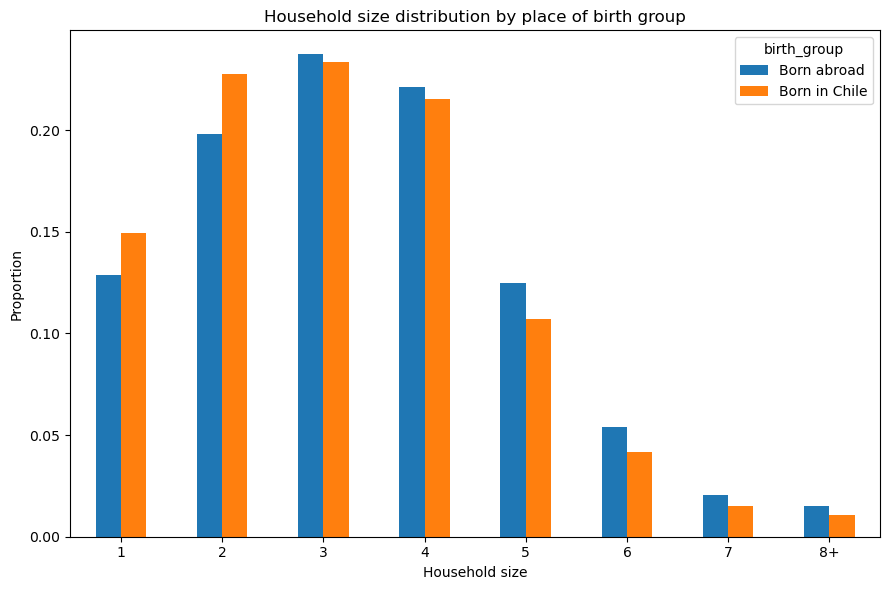

birth_group,Born abroad,Born in Chile
household_size_cat,,
1,0.128947,0.149211
2,0.198053,0.227659
3,0.237238,0.233341
4,0.221186,0.215523
5,0.124993,0.107155
6,0.054175,0.041450
7,0.020419,0.014920
8+,0.014990,0.010740


In [32]:
# 1) Tamaño del hogar = número de personas por hogar
hh_size = (
    df.groupby(["id_vivienda", "id_hogar"])
      .size()
      .reset_index(name="household_size")
)

# 2) Nos quedamos solo con valores válidos de lugar de nacimiento
# Ajusta los códigos si en tu base no son 1 = born in Chile, 2 = born abroad
birth_valid = df[df["p25_lug_nacimiento_rec"].isin([1, 2])].copy()

# 3) Para la opción "all members":
# cada hogar queda asociado a cada grupo presente en ese hogar,
# pero SOLO una vez por grupo (para no contar personas, sino hogares)
hh_birth_group = (
    birth_valid[["id_vivienda", "id_hogar", "p25_lug_nacimiento_rec"]]
    .drop_duplicates()
)

# 4) Unir el tamaño del hogar con el grupo de lugar de nacimiento
hh_dist = hh_size.merge(
    hh_birth_group,
    on=["id_vivienda", "id_hogar"],
    how="inner"
)

# 5) Crear categoría 8+
hh_dist["household_size_cat"] = hh_dist["household_size"].apply(
    lambda x: "8+" if x >= 8 else str(x)
)

# 6) Orden correcto del eje x
order = [str(i) for i in range(1, 8)] + ["8+"]

# 7) Etiquetas del grupo
hh_dist["birth_group"] = hh_dist["p25_lug_nacimiento_rec"].map({
    1: "Born in Chile",
    2: "Born abroad"
})

# 8) Contar hogares por tamaño y grupo
dist = (
    hh_dist.groupby(["household_size_cat", "birth_group"])
           .size()
           .reset_index(name="count")
)

# 9) Pivot para graficar
dist_pivot = dist.pivot(
    index="household_size_cat",
    columns="birth_group",
    values="count"
).fillna(0)

dist_pivot = dist_pivot.reindex(order)

# 10) Pasar a proporciones dentro de cada grupo
dist_prop = dist_pivot.div(dist_pivot.sum(axis=0), axis=1)

# 11) Gráfico
dist_prop.plot(kind="bar", figsize=(9, 6))
plt.xlabel("Household size")
plt.ylabel("Proportion")
plt.title("Household size distribution by place of birth group")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 12) Tabla de apoyo
dist_prop

Construye la distribución del tamaño de los hogares según grupo de lugar de nacimiento .La diferencia que se puede observar es que las el grupo de personas nacidas en el extranjero desde las 3 personas en adelante superan al grupo de personas nacidas en Chile, además el grupo de Chile lidera las de 1 y 2 personas.

#### 1.4 --> Education and employment (1 pt)


1) Mean years of schooling


birth_group,Born abroad,Born in Chile
comuna,,
Colina,12.78,12.61
Melipilla,11.26,11.07
Talagante,12.26,11.83


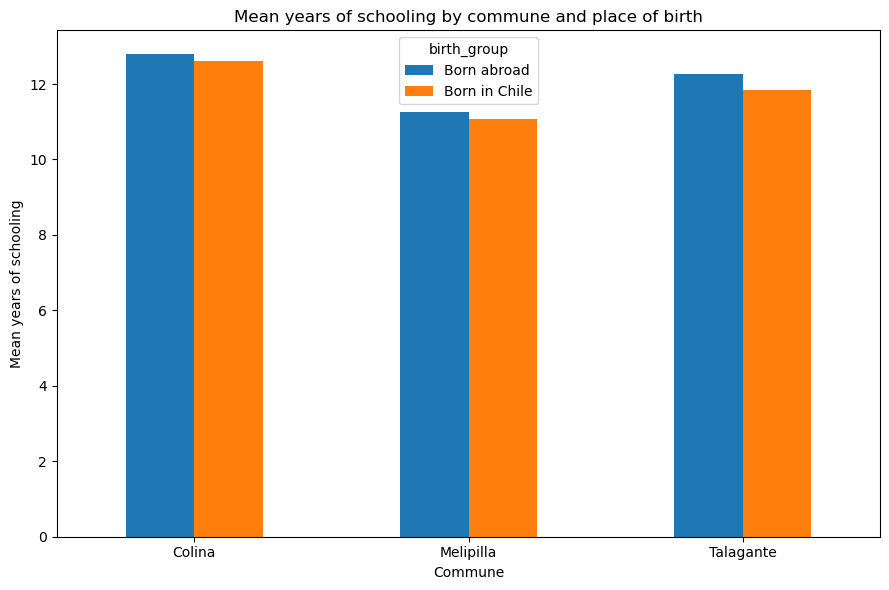

2) Employment rate


birth_group,Born abroad,Born in Chile
comuna,,
Colina,70.00,59.95
Melipilla,74.38,58.93
Talagante,69.74,59.75


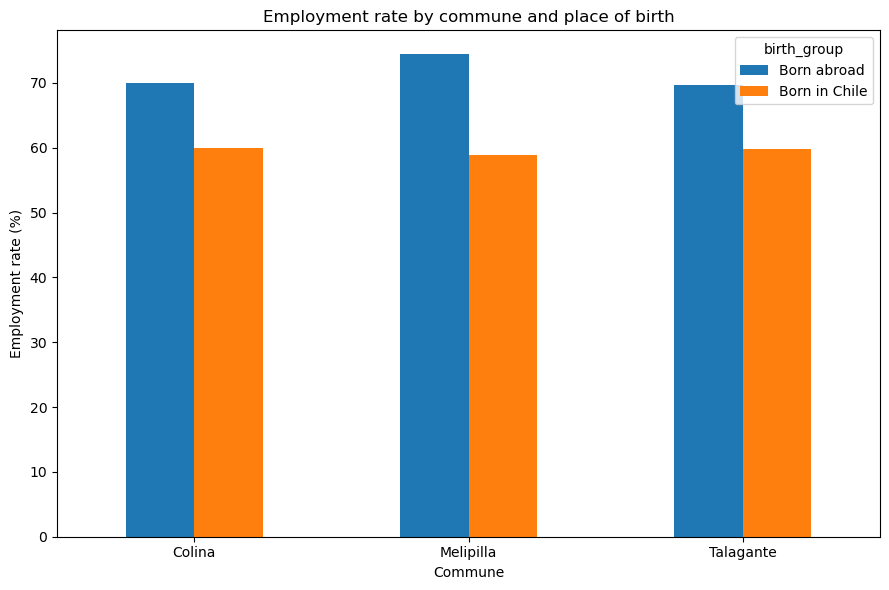

In [33]:
# ============================================================
# Variable correcta: lugar de nacimiento
# ============================================================
if "p25_lug_nacimiento_rec" in df.columns:
    birth_var = "p25_lug_nacimiento_rec"
elif "p25_lug_nacimiento" in df.columns:
    birth_var = "p25_lug_nacimiento"
else:
    raise KeyError("No se encontró ni p25_lug_nacimiento_rec ni p25_lug_nacimiento en df.")

# Copia de trabajo
edu_emp = df.copy()

# Si comuna sigue con código, la renombramos solo aquí
commune_map = {
    13301: "Colina",
    13501: "Melipilla",
    13601: "Talagante"
}
edu_emp["comuna"] = edu_emp["comuna"].replace(commune_map)

# Dejar solo nacidos en Chile / nacidos fuera de Chile
edu_emp = edu_emp[edu_emp[birth_var].isin([1, 2])].copy()

edu_emp["birth_group"] = edu_emp[birth_var].map({
    1: "Born in Chile",
    2: "Born abroad"
})

commune_order = ["Colina", "Melipilla", "Talagante"]

# ============================================================
# 1) Mean years of schooling (population aged 25+)
# ============================================================
schooling = edu_emp[
    (edu_emp["edad"] >= 25) &
    (edu_emp["edad"] != -99) &
    (edu_emp["escolaridad"] != -99)
].copy()

schooling_table = (
    schooling
    .groupby(["comuna", "birth_group"])["escolaridad"]
    .mean()
    .reset_index()
)

schooling_pivot = schooling_table.pivot(
    index="comuna",
    columns="birth_group",
    values="escolaridad"
).reindex(commune_order)

print("1) Mean years of schooling")
display(schooling_pivot.round(2))

schooling_pivot.plot(kind="bar", figsize=(9, 6))
plt.title("Mean years of schooling by commune and place of birth")
plt.xlabel("Commune")
plt.ylabel("Mean years of schooling")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# ============================================================
# 2) Employment rate (population aged 15-64)
# OJO: asumo que 1 = employed en sit_fuerza_trabajo
# Si tu diccionario dice otro código, cambia employed_code
# ============================================================
employed_code = 1

employment = edu_emp[
    (edu_emp["edad"] >= 15) &
    (edu_emp["edad"] <= 64) &
    (edu_emp["edad"] != -99) &
    (edu_emp["sit_fuerza_trabajo"] != -99)
].copy()

employment["is_employed"] = (employment["sit_fuerza_trabajo"] == employed_code).astype(int)

employment_table = (
    employment
    .groupby(["comuna", "birth_group"])["is_employed"]
    .mean()
    .reset_index(name="employment_rate")
)

employment_pivot = employment_table.pivot(
    index="comuna",
    columns="birth_group",
    values="employment_rate"
).reindex(commune_order)

print("2) Employment rate")
display((employment_pivot * 100).round(2))

(employment_pivot * 100).plot(kind="bar", figsize=(9, 6))
plt.title("Employment rate by commune and place of birth")
plt.xlabel("Commune")
plt.ylabel("Employment rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Se comparan la escolaridad promedio y la tasa de empleo entre personas nacidas en Chile y nacidas en el extranjero en Colina, Melipilla y Talagante. Además, los resultados se muestran en tablas y gráficos para comparar ambos grupos en cada comuna.
1) Las personas nacidas fuera de Chile que tienen 25 años o más presentan, en promedio, algo más de escolaridad que las nacidas en Chile.
2) Las personas nacidas fuera de Chile que tienen entre 15 y 64 tienen una mayor proporción de ocupados que los las personas nacidas en Chile.

In [34]:
df["sit_fuerza_trabajo"].value_counts(dropna=False).sort_index()

sit_fuerza_trabajo
-99.0      2050
 1.0     166235
 2.0      14324
 3.0     121340
 NaN      82098
Name: count, dtype: int64

Se revisa la variable de situación laboral para ver qué valores tiene y detectar datos faltantes o no válidos antes de calcular la tasa de empleo.

- 1 --> Ocupado
- 2 --> Desocupado
- 3 --> Fuera de la fuerza de trabajo
- -99 --> No respuesta
- NA --> No aplica

## Part 2: Migration Landscape (3 pts)


#### 2.1 --> Percentage foreign-born by comuna (0.5 pts)


In [35]:
# ============================================================
# Variable correcta: lugar de nacimiento
# ============================================================
if "p25_lug_nacimiento_rec" in df.columns:
    birth_var = "p25_lug_nacimiento_rec"
elif "p25_lug_nacimiento" in df.columns:
    birth_var = "p25_lug_nacimiento"
else:
    raise KeyError("No se encontró ni p25_lug_nacimiento_rec ni p25_lug_nacimiento en df.")

# Copia de trabajo
foreign_df = df.copy()

# Dejar comunas con nombre, por si aún están con código
commune_map = {
    13301: "Colina",
    13501: "Melipilla",
    13601: "Talagante"
}
foreign_df["comuna"] = foreign_df["comuna"].replace(commune_map)

# Dejar solo valores válidos de lugar de nacimiento
foreign_df = foreign_df[foreign_df[birth_var].isin([1, 2])].copy()

# Crear indicador: 1 si nació fuera de Chile, 0 si nació en Chile
foreign_df["foreign_born"] = (foreign_df[birth_var] == 2).astype(int)

# Calcular porcentaje por comuna
foreign_table = (
    foreign_df.groupby("comuna")["foreign_born"]
              .mean()
              .reset_index(name="percentage_foreign_born")
)

# Pasar a porcentaje
foreign_table["percentage_foreign_born"] = foreign_table["percentage_foreign_born"] * 100

# Ordenar
commune_order = ["Colina", "Melipilla", "Talagante"]
foreign_table["comuna"] = pd.Categorical(
    foreign_table["comuna"],
    categories=commune_order,
    ordered=True
)
foreign_table = foreign_table.sort_values("comuna")

# Tabla final
foreign_table["percentage_foreign_born"] = foreign_table["percentage_foreign_born"].round(2)
foreign_table = foreign_table.rename(columns={
    "comuna": "Comuna",
    "percentage_foreign_born": "Percentage foreign-born"
})

foreign_table


,Comuna,Percentage foreign-born
0,Colina,13.09
1,Melipilla,8.17
2,Talagante,6.01


Se calcula el porcentaje de personas nacidas en el extranjero en cada comuna, considerando solo los casos con lugar de nacimiento válido. Colina tiene la mayor porcentaje de personas nacidas en el extranjero.

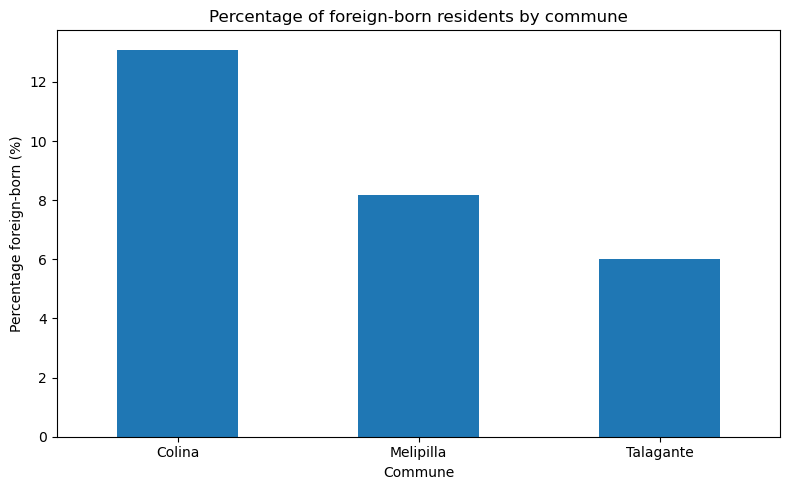

In [36]:
foreign_table.plot(
    x="Comuna",
    y="Percentage foreign-born",
    kind="bar",
    legend=False,
    figsize=(8, 5)
)

plt.title("Percentage of foreign-born residents by commune")
plt.xlabel("Commune")
plt.ylabel("Percentage foreign-born (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Es la representación gráfica de los calculos obtenidos anteriormente, en donde se observa mejor como Colina es el mayor.

#### 2.2 --> Top nationalities (1 pt)


Filas después de filtrar comunas: 386047
Filas nacidos en el extranjero con nacionalidad válida: 38082
comuna_nombre
Colina       22461
Melipilla    11065
Talagante     4556
Name: count, dtype: int64

Top 10 - Colina


,Nationality,Count
0,Venezuela (República Bolivariana de),4103
1,Perú,3373
2,Bolivia (Estado Plurinacional de),2870
3,Colombia,2827
4,Chile,2524
5,Haití,2107
6,Otros países de América del Sur,1451
7,Argentina,1306
8,Otros países de América Central y El Caribe,1163
9,Europa,436


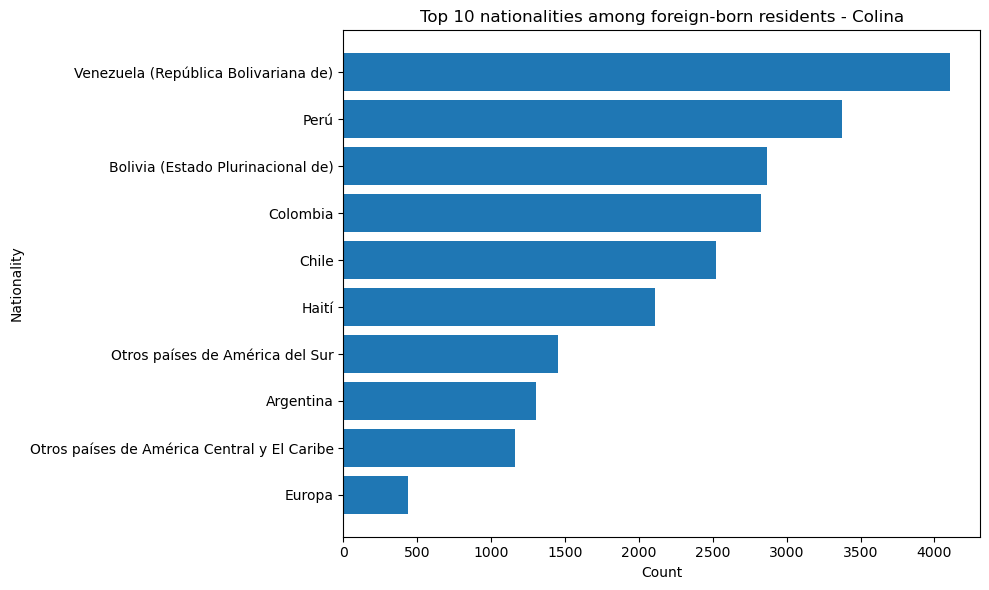


Top 10 - Melipilla


,Nationality,Count
0,Bolivia (Estado Plurinacional de),4632
1,Venezuela (República Bolivariana de),2622
2,Haití,1266
3,Chile,712
4,Colombia,606
5,Perú,533
6,Otros países de América del Sur,270
7,Otros países de América Central y El Caribe,174
8,Argentina,134
9,Europa,62


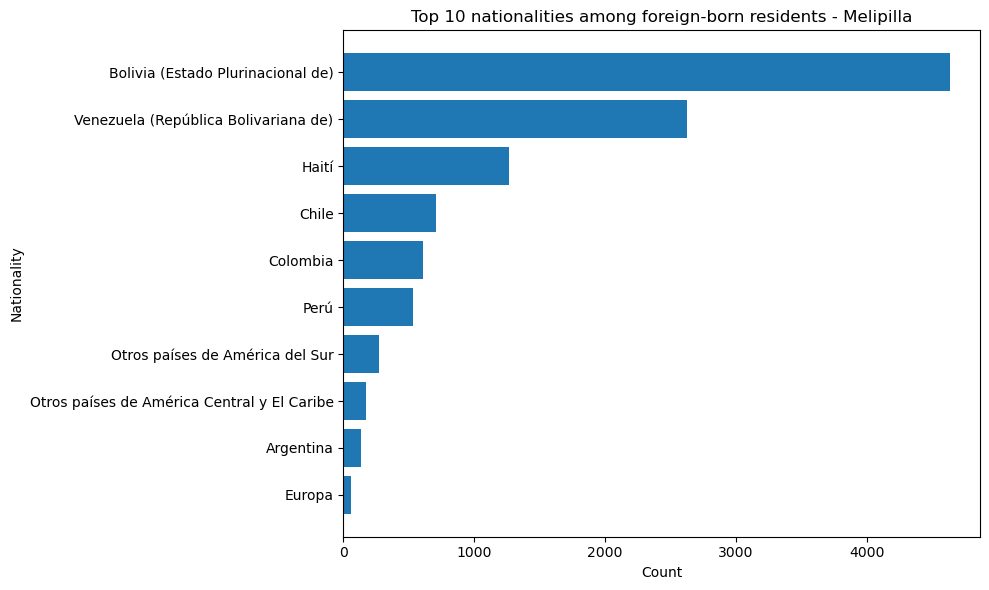


Top 10 - Talagante


,Nationality,Count
0,Venezuela (República Bolivariana de),1914
1,Haití,619
2,Chile,496
3,Colombia,490
4,Otros países de América del Sur,289
5,Perú,279
6,Bolivia (Estado Plurinacional de),147
7,Otros países de América Central y El Caribe,134
8,Argentina,64
9,Europa,52


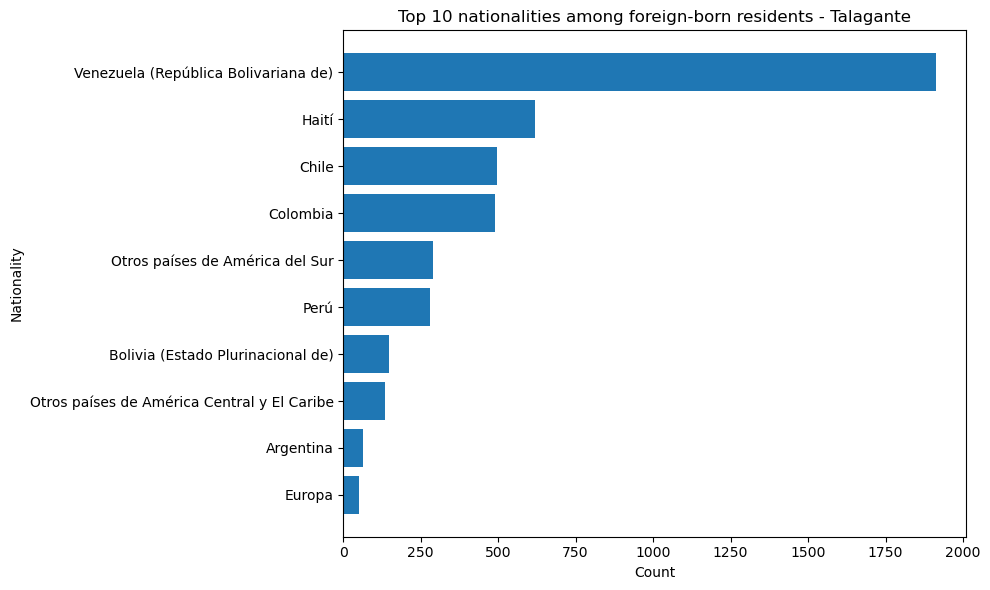


Top 10 - Total (3 comunas juntas)


,Nationality,Count
0,Venezuela (República Bolivariana de),8639
1,Bolivia (Estado Plurinacional de),7649
2,Perú,4185
3,Haití,3992
4,Colombia,3923
5,Chile,3732
6,Otros países de América del Sur,2010
7,Argentina,1504
8,Otros países de América Central y El Caribe,1471
9,Europa,550


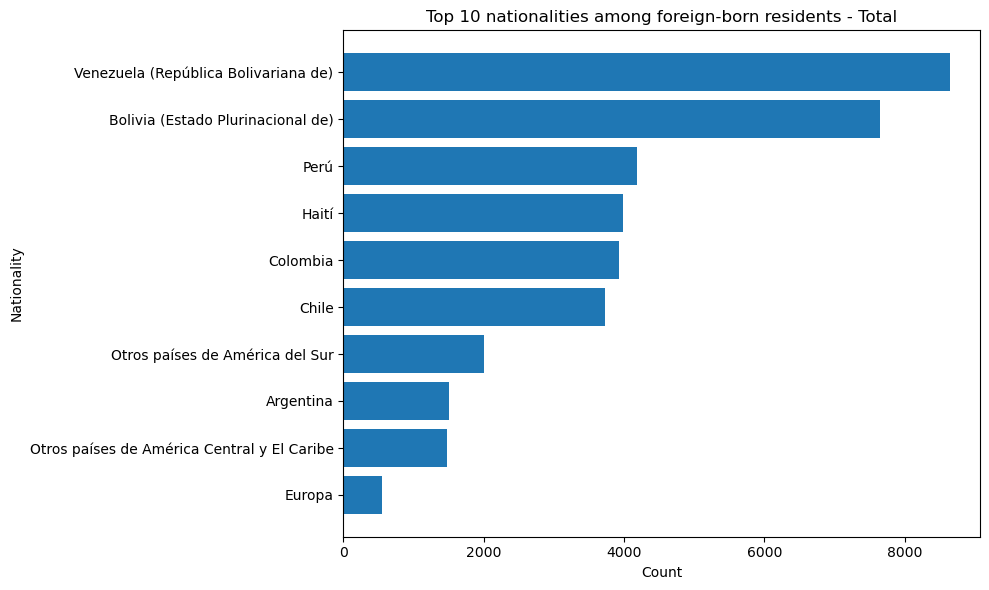

In [37]:
# ============================================================
# Diccionario de nacionalidades / territorios específicos
# ============================================================
dic_terr = pd.read_excel(
    "../Datos/diccionario_variables_censo2024.xlsx",
    sheet_name="cod_territoriales_especificos"
)

dic_terr["Código específico"] = pd.to_numeric(dic_terr["Código específico"], errors="coerce")
territorio_map = dict(zip(
    dic_terr["Código específico"],
    dic_terr["Territorio específico"]
))

# ============================================================
# Comunas de interés
# ============================================================
comuna_map = {
    13301: "Colina",
    13501: "Melipilla",
    13601: "Talagante"
}
comunas_nombre = ["Colina", "Melipilla", "Talagante"]

# ============================================================
# Base inicial: detectar si comuna está en código o nombre
# ============================================================
base = df.copy()

if pd.api.types.is_numeric_dtype(base["comuna"]):
    base = base[base["comuna"].isin(comuna_map.keys())].copy()
    base["comuna_nombre"] = base["comuna"].map(comuna_map)
else:
    base["comuna_nombre"] = base["comuna"].astype(str).str.strip()
    base = base[base["comuna_nombre"].isin(comunas_nombre)].copy()

# ============================================================
# Asegurar que p27_nacionalidad_esp sea numérica
# ============================================================
base["p27_nacionalidad_esp"] = pd.to_numeric(base["p27_nacionalidad_esp"], errors="coerce")

# ============================================================
# Filtrar:
# - nacidos en el extranjero
# - nacionalidad detallada válida
# ============================================================
top_nat_df = base[
    (base["p25_lug_nacimiento_rec"] == 2) &
    (base["p27_nacionalidad_esp"].notna()) &
    (~base["p27_nacionalidad_esp"].isin([-99, -66]))
].copy()

# Mapear nombre de nacionalidad
top_nat_df["nationality_name"] = top_nat_df["p27_nacionalidad_esp"].map(territorio_map)

# Si algún código no aparece en el diccionario, dejar el código como texto
top_nat_df["nationality_name"] = top_nat_df["nationality_name"].fillna(
    top_nat_df["p27_nacionalidad_esp"].astype("Int64").astype(str)
)

# ============================================================
# Revisiones rápidas
# ============================================================
print("Filas después de filtrar comunas:", len(base))
print("Filas nacidos en el extranjero con nacionalidad válida:", len(top_nat_df))
print(top_nat_df["comuna_nombre"].value_counts(dropna=False))

# ============================================================
# Top 10 por comuna
# ============================================================
for comuna in comunas_nombre:
    temp = top_nat_df[top_nat_df["comuna_nombre"] == comuna].copy()

    top10_comuna = (
        temp["nationality_name"]
        .value_counts()
        .head(10)
        .reset_index()
    )
    top10_comuna.columns = ["Nationality", "Count"]

    print(f"\nTop 10 - {comuna}")
    display(top10_comuna)

    if not top10_comuna.empty:
        plt.figure(figsize=(10, 6))
        plt.barh(top10_comuna["Nationality"], top10_comuna["Count"])
        plt.gca().invert_yaxis()
        plt.xlabel("Count")
        plt.ylabel("Nationality")
        plt.title(f"Top 10 nationalities among foreign-born residents - {comuna}")
        plt.tight_layout()
        plt.show()
    else:
        print(f"No hay datos para {comuna}")

# ============================================================
# Top 10 total de las 3 comunas
# ============================================================
top10_total = (
    top_nat_df["nationality_name"]
    .value_counts()
    .head(10)
    .reset_index()
)
top10_total.columns = ["Nationality", "Count"]

print("\nTop 10 - Total (3 comunas juntas)")
display(top10_total)

if not top10_total.empty:
    plt.figure(figsize=(10, 6))
    plt.barh(top10_total["Nationality"], top10_total["Count"])
    plt.gca().invert_yaxis()
    plt.xlabel("Count")
    plt.ylabel("Nationality")
    plt.title("Top 10 nationalities among foreign-born residents - Total")
    plt.tight_layout()
    plt.show()
else:
    print("No hay datos en el total")

Se identifican las nacionalidades más frecuentes entre la población nacida en el extranjero en Colina, Melipilla y Talagante, mostrando el top 10 por comuna y también en el total de las tres comunas. Se pbtiene lo siguiente:

- En Colina la nacionalidad más frecuentes es Venezuela.
- En Melipilla la nacionalidad más frecuente es Bolivia.
- En Talagante la nacionalidad más frecuente es Venezuela.

Y en general la nacionalidad que más frecuente de las 3 comunas en conjunto es Venezuela.

#### 2.3 --> Migration status: residence 5 years ago (1 pt)


In [38]:
import numpy as np

required_cols = ["edad", "p24_lug_resid5", "p24_lug_resid5_esp", "comuna", "region"]
for col in required_cols:
    if col not in df.columns:
        raise KeyError(f"Falta la columna {col} en df.")

mig = df.copy()

comuna_map = {
    13301: "Colina",
    13501: "Melipilla",
    13601: "Talagante"
}
mig["comuna"] = mig["comuna"].replace(comuna_map)

cod_terr = pd.read_excel(
    "../Datos/diccionario_variables_censo2024.xlsx",
    sheet_name="codigos_territoriales"
)

cod_comunas = cod_terr[cod_terr["División Política Administrativa"] == "Comuna"].copy()
valid_comuna_codes = set(cod_comunas["Código territorial"].astype(int))

mig = mig[
    (mig["edad"] >= 5) &
    (mig["p24_lug_resid5"].isin([2, 3, 4]))
].copy()

if pd.api.types.is_numeric_dtype(mig["region"]):
    mig["current_region_code"] = mig["region"].astype("Int64")
else:
    mig["current_region_code"] = 13

def get_old_region(code):
    if pd.isna(code):
        return np.nan
    try:
        code = int(code)
    except:
        return np.nan

    if code in valid_comuna_codes:
        return code // 1000

    return np.nan

mig["old_region_code"] = mig["p24_lug_resid5_esp"].apply(get_old_region)

def classify_status(row):
    if row["p24_lug_resid5"] == 2:
        return "Same comuna"

    if row["p24_lug_resid5"] == 4:
        return "Abroad"

    if row["p24_lug_resid5"] == 3:
        if pd.isna(row["old_region_code"]):
            return np.nan
        if row["old_region_code"] == row["current_region_code"]:
            return "Different comuna, same region"
        return "Different region"

    return np.nan

mig["migration_status"] = mig.apply(classify_status, axis=1)

mig = mig.dropna(subset=["migration_status"]).copy()

status_order = [
    "Same comuna",
    "Different comuna, same region",
    "Different region",
    "Abroad"
]

migration_table = (
    mig.groupby(["comuna", "migration_status"])
       .size()
       .reset_index(name="count")
)

migration_table["percentage"] = (
    migration_table.groupby("comuna")["count"]
                   .transform(lambda x: 100 * x / x.sum())
)

migration_pivot = migration_table.pivot(
    index="comuna",
    columns="migration_status",
    values="percentage"
).fillna(0)

migration_pivot = migration_pivot.reindex(
    ["Colina", "Melipilla", "Talagante"]
).reindex(columns=status_order)

migration_pivot = migration_pivot.round(2)

migration_pivot

migration_status,Same comuna,"Different comuna, same region",Different region,Abroad
comuna,,,,
Colina,77.53,15.55,2.39,4.54
Melipilla,86.74,7.41,1.74,4.11
Talagante,84.56,11.69,1.33,2.42


Se construye la tabla de estatus migratorio según dónde vivía la persona hace 5 años.

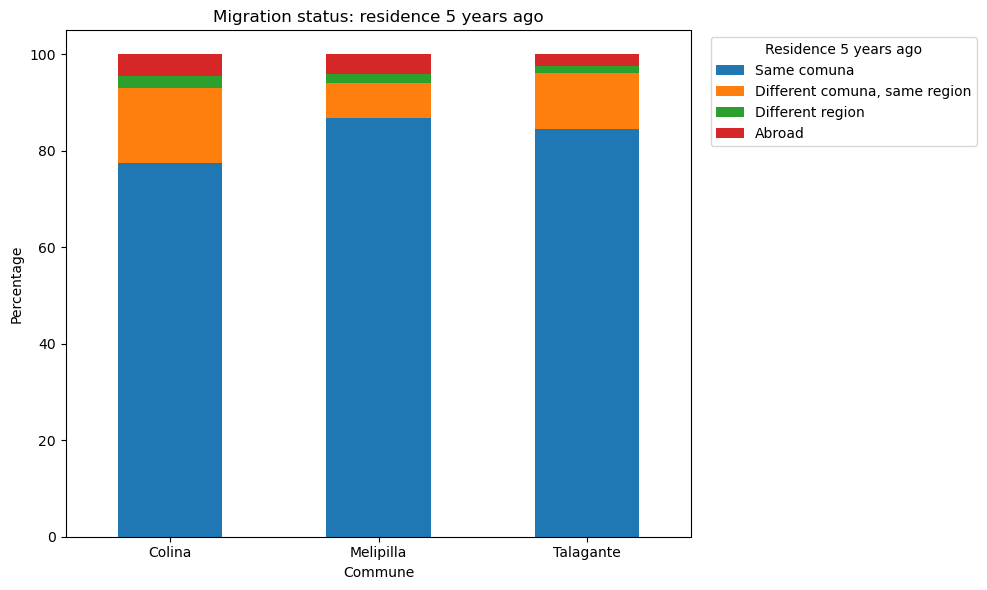

In [39]:
migration_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Migration status: residence 5 years ago")
plt.xlabel("Commune")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Residence 5 years ago", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

Es la representación gráfica de lo obtenido en la celda anterior. En donde se obtiene que la gran mayoría se mantiene en la misma comuna.

#### 2.4 --> Arrival period of immigrants (0.5 pts)

In [40]:
# ============================================================
# 2.4 Arrival period of immigrants
# ============================================================

# ------------------------------------------------------------
# 1) Leer etiquetas de p26 desde el diccionario
# ------------------------------------------------------------
dic_personas = pd.read_excel(
    "../Datos/diccionario_variables_censo2024.xlsx",
    sheet_name="tabla_personas"
)

p26_dic = dic_personas[
    dic_personas["Nombre variable"] == "p26_llegada_periodo"
].copy()

# Dejar solo códigos válidos 1 a 8
p26_dic = p26_dic[p26_dic["Valor"].isin([1, 2, 3, 4, 5, 6, 7, 8])].copy()

arrival_map = dict(zip(
    p26_dic["Valor"],
    p26_dic["Etiqueta de categoría"]
))

arrival_order = [1, 2, 3, 4, 5, 6, 7, 8]
arrival_labels = [arrival_map[i] for i in arrival_order]

# ------------------------------------------------------------
# 2) Filtrar foreign-born con periodo de llegada válido
# ------------------------------------------------------------
imm = df[
    (df["p25_lug_nacimiento_rec"] == 2) &
    (df["p26_llegada_periodo"].isin(arrival_order))
].copy()

# Renombrar comunas si siguen con código
comuna_map = {
    13301: "Colina",
    13501: "Melipilla",
    13601: "Talagante"
}
imm["comuna"] = imm["comuna"].replace(comuna_map)

# Crear etiqueta legible
imm["arrival_period"] = imm["p26_llegada_periodo"].map(arrival_map)

# ------------------------------------------------------------
# 3) Tabla total
# ------------------------------------------------------------
arrival_total = (
    imm["arrival_period"]
    .value_counts()
    .reindex(arrival_labels)
    .reset_index()
)

arrival_total.columns = ["Arrival period", "Count"]
arrival_total["Percentage"] = (arrival_total["Count"] / arrival_total["Count"].sum() * 100).round(2)

arrival_total

,Arrival period,Count,Percentage
0,Entre 2023 y 2024,5479,14.42
1,Entre 2020 y 2022,8392,22.09
2,Entre 2017 y 2019,11607,30.56
3,Entre 2014 y 2016,5150,13.56
4,Entre 2010 y 2013,2631,6.93
5,Entre 2000 y 2009,2745,7.23
6,Entre 1990 y 1999,1162,3.06
7,Antes de 1990,818,2.15


Se analiza el periodo de llegada de la población nacida en el extranjero, contando cuántas personas pertenecen a cada intervalo de tiempo y qué porcentaje representan del total. En el año que más extranjeros llegaron fue entre el 2017 y 2019.

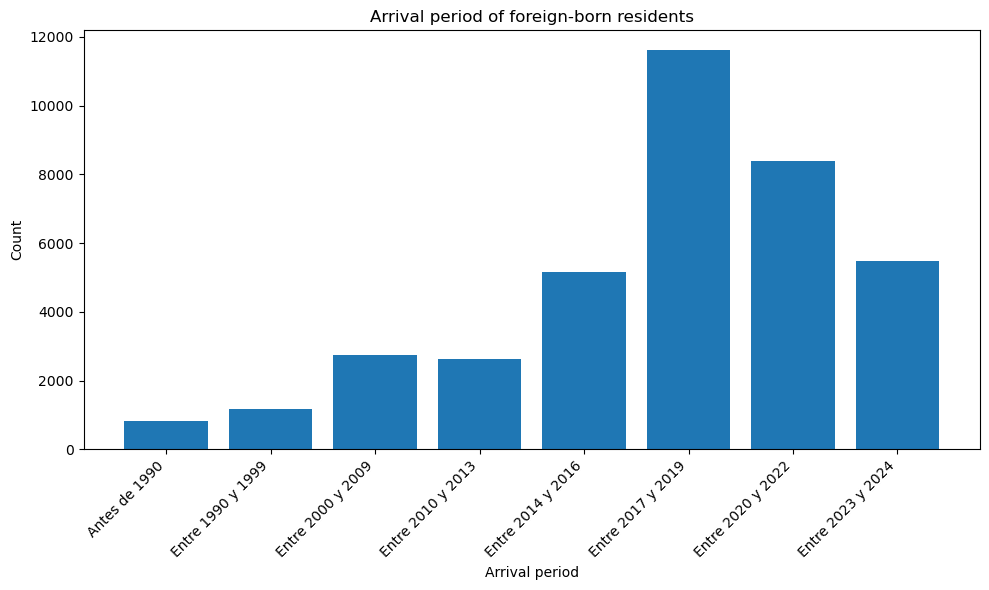

In [41]:
plt.figure(figsize=(10, 6))
plt.bar(arrival_total["Arrival period"][::-1], arrival_total["Count"][::-1])
plt.xlabel("Arrival period")
plt.ylabel("Count")
plt.title("Arrival period of foreign-born residents")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Es la representación gráfica de los resultados de la celda anterior, en donde se ve como lidera el periodo entre 2017 y 2019.

In [42]:
arrival_by_comuna = (
    imm.groupby(["comuna", "arrival_period"])
       .size()
       .reset_index(name="count")
)

arrival_by_comuna["percentage"] = (
    arrival_by_comuna.groupby("comuna")["count"]
                     .transform(lambda x: 100 * x / x.sum())
)

arrival_pivot = arrival_by_comuna.pivot(
    index="arrival_period",
    columns="comuna",
    values="percentage"
).fillna(0)

arrival_pivot = arrival_pivot.reindex(arrival_labels)

arrival_pivot

comuna,Colina,Melipilla,Talagante
arrival_period,,,
Entre 2023 y 2024,11.396813,20.703090,14.100308
Entre 2020 y 2022,19.615196,26.538009,23.515178
Entre 2017 y 2019,27.244319,35.136360,35.767708
Entre 2014 y 2016,16.686755,8.734257,9.854817
Entre 2010 y 2013,9.334405,2.962762,4.685438
Entre 2000 y 2009,9.521896,3.225514,5.631324
Entre 1990 y 1999,3.615910,1.658059,3.717554
Antes de 1990,2.584706,1.041950,2.727673


Al igual que antes, es el mismo análisis pero por comuna, pero solo en porcentajes, en donde en todos los caso es superior entre 2017 y 2019.

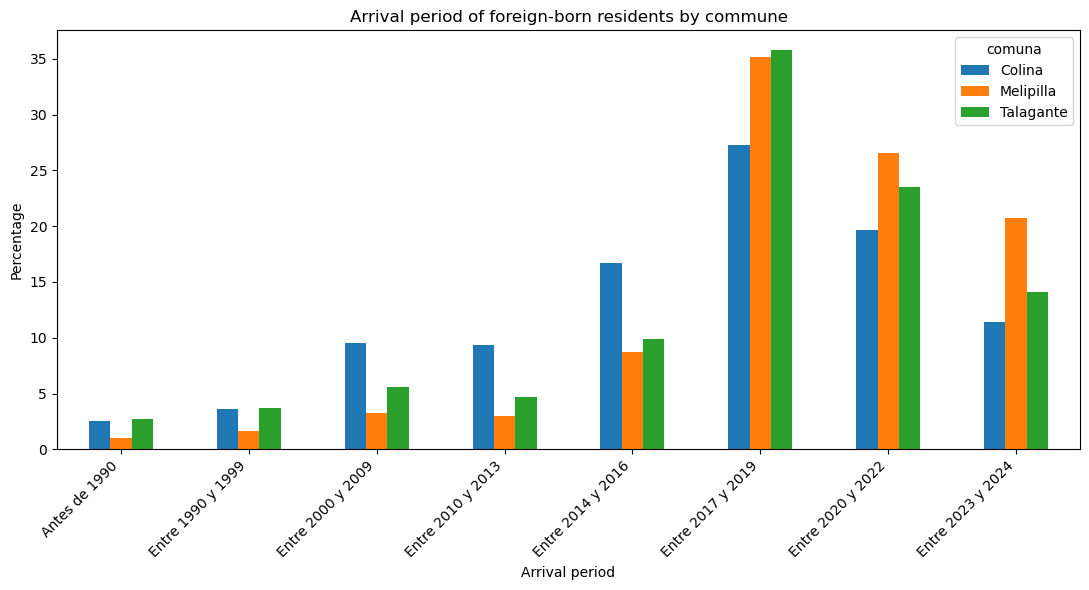

In [43]:
arrival_pivot[::-1].plot(kind="bar", figsize=(11, 6))
plt.xlabel("Arrival period")
plt.ylabel("Percentage")
plt.title("Arrival period of foreign-born residents by commune")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

La representación gráfica de lo obtenido en la celda anterior. Como se puede observar en las diferentes comunas, la inmigración ha sido un fenómeno que se ha dado desde hace bastante tiempo, la diferencia es que aproximadamente desde el año 2016 hasta el 2024 hubo un gran incremento de inmigración en estas comunas.

## Part 3: Spatial Visualization (1 pt)


#### 3.1 --> Choropleth map: population by comuna


In [44]:
import geopandas as gpd
from pathlib import Path

# Tabla de población por comuna
pop_df = df.copy()

name_to_code = {
    "Colina": 13301,
    "Melipilla": 13501,
    "Talagante": 13601
}

code_to_name = {
    13301: "Colina",
    13501: "Melipilla",
    13601: "Talagante"
}

# Si comuna viene con nombres, la transforma; si ya viene con códigos, conserva el valor
pop_df["comuna_cod"] = pop_df["comuna"].replace(name_to_code)

# Intentar pasar a numérico
pop_df["comuna_cod"] = pd.to_numeric(pop_df["comuna_cod"], errors="coerce")

# Contar población total por comuna
pop_table = (
    pop_df.groupby("comuna_cod")
          .size()
          .reset_index(name="population")
)

pop_table["comuna_nombre"] = pop_table["comuna_cod"].map(code_to_name)

pop_table

,comuna_cod,population,comuna_nombre
0,13301,173293,Colina
1,13501,136325,Melipilla
2,13601,76429,Talagante


"Prepara" la tabla de población total por comuna para después hacer el mapa. En donde la mayor cantidad de habitantes la tiene Colina.

In [45]:
comunas_gdf = gpd.read_file("../Datos/comunas.shp")
comunas_gdf.head()


,objectid,shape_leng,dis_elec,cir_sena,cod_comuna,codregion,st_area_sh,st_length_,Region,Comuna,Provincia,geometry
0,48,170038.624165,16,8,6204,6,9.685774e+08,206184.271675,Región del Libertador Bernardo O'Higgins,Marchigüe,Cardenal Caro,"POLYGON ((-7992818.789 -4056669.319, -7992731...."
1,29,125730.104795,15,8,6102,6,4.157446e+08,151911.576827,Región del Libertador Bernardo O'Higgins,Codegua,Cachapoal,"POLYGON ((-7831651.813 -4022443.109, -7831596...."
2,30,63026.084422,15,8,6103,6,1.448565e+08,76355.326122,Región del Libertador Bernardo O'Higgins,Coinco,Cachapoal,"POLYGON ((-7892616.357 -4060673.364, -7892621...."
3,31,89840.903562,15,8,6104,6,3.256572e+08,108874.623150,Región del Libertador Bernardo O'Higgins,Coltauco,Cachapoal,"POLYGON ((-7906457.717 -4051723.734, -7906266...."
4,78,122626.493264,23,11,9121,9,6.990727e+08,156680.410681,Región de La Araucanía,Cholchol,Cautín,"POLYGON ((-8121756.186 -4645860.295, -8121644...."


Se carga el archivo geográfico de las comunas.

In [46]:
comunas_gdf.columns.tolist()

['objectid',
 'shape_leng',
 'dis_elec',
 'cir_sena',
 'cod_comuna',
 'codregion',
 'st_area_sh',
 'st_length_',
 'Region',
 'Comuna',
 'Provincia',
 'geometry']

Sirve para ver los nombres de las columnas que tiene comunas_gdf.

In [47]:
target_codes = [13301, 13501, 13601]

map_gdf = comunas_gdf[comunas_gdf["cod_comuna"].isin(target_codes)].copy()

map_gdf = map_gdf.merge(
    pop_table,
    left_on="cod_comuna",
    right_on="comuna_cod",
    how="left"
)

map_gdf[["cod_comuna", "Comuna", "population"]]

,cod_comuna,Comuna,population
0,13301,Colina,173293
1,13601,Talagante,76429
2,13501,Melipilla,136325


Seleccionan las tres comunas analizadas dentro del archivo geográfico y se agrega la población total, dejando la base lista para construir el mapa.

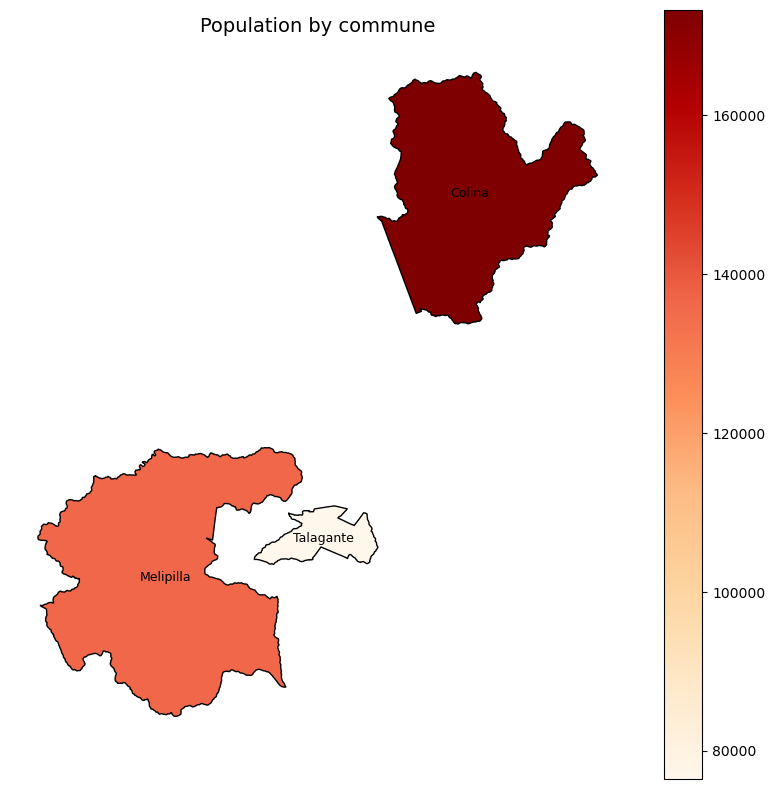

In [48]:
fig, ax = plt.subplots(figsize=(8, 8))

map_gdf.plot(
    column="population",
    cmap="OrRd",
    linewidth=1,
    edgecolor="black",
    legend=True,
    ax=ax
)

for _, row in map_gdf.iterrows():
    centroid = row.geometry.centroid
    ax.text(
        centroid.x,
        centroid.y,
        row["Comuna"],
        fontsize=9,
        ha="center",
        va="center"
    )

ax.set_title("Population by commune", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.show()

Se construye un mapa coroplético que muestra la población total de cada comuna, usando distintos tonos para representar su magnitud. Donde se puede observar que Colina es la que más habitantes tiene, seguido de Melipilla y Talagante.

#### 3.2 --> Choropleth map: % foreign-born by comuna


In [49]:
foreign_df = df.copy()

name_to_code = {
    "Colina": 13301,
    "Melipilla": 13501,
    "Talagante": 13601
}

code_to_name = {
    13301: "Colina",
    13501: "Melipilla",
    13601: "Talagante"
}

foreign_df["comuna_cod"] = foreign_df["comuna"].replace(name_to_code)
foreign_df["comuna_cod"] = pd.to_numeric(foreign_df["comuna_cod"], errors="coerce")

foreign_df = foreign_df[foreign_df["p25_lug_nacimiento_rec"].isin([1, 2])].copy()

foreign_df["foreign_born"] = (foreign_df["p25_lug_nacimiento_rec"] == 2).astype(int)

foreign_table = (
    foreign_df.groupby("comuna_cod")["foreign_born"]
              .mean()
              .reset_index(name="pct_foreign_born")
)

foreign_table["pct_foreign_born"] = foreign_table["pct_foreign_born"] * 100
foreign_table["comuna_nombre"] = foreign_table["comuna_cod"].map(code_to_name)

foreign_table

,comuna_cod,pct_foreign_born,comuna_nombre
0,13301,13.089669,Colina
1,13501,8.170451,Melipilla
2,13601,6.008092,Talagante


Se calcula el porcentaje de población nacida en el extranjero en cada comuna, dejando una tabla base que luego se usará para construir el segundo mapa. En donde lidera Colina.

In [50]:
target_codes = [13301, 13501, 13601]

map_foreign_gdf = comunas_gdf[comunas_gdf["cod_comuna"].isin(target_codes)].copy()

map_foreign_gdf = map_foreign_gdf.merge(
    foreign_table,
    left_on="cod_comuna",
    right_on="comuna_cod",
    how="left"
)

map_foreign_gdf[["cod_comuna", "Comuna", "pct_foreign_born"]]

,cod_comuna,Comuna,pct_foreign_born
0,13301,Colina,13.089669
1,13601,Talagante,6.008092
2,13501,Melipilla,8.170451


Se seleccionan las tres comunas analizadas dentro del archivo geográfico y se les incorpora el porcentaje de población nacida en el extranjero.

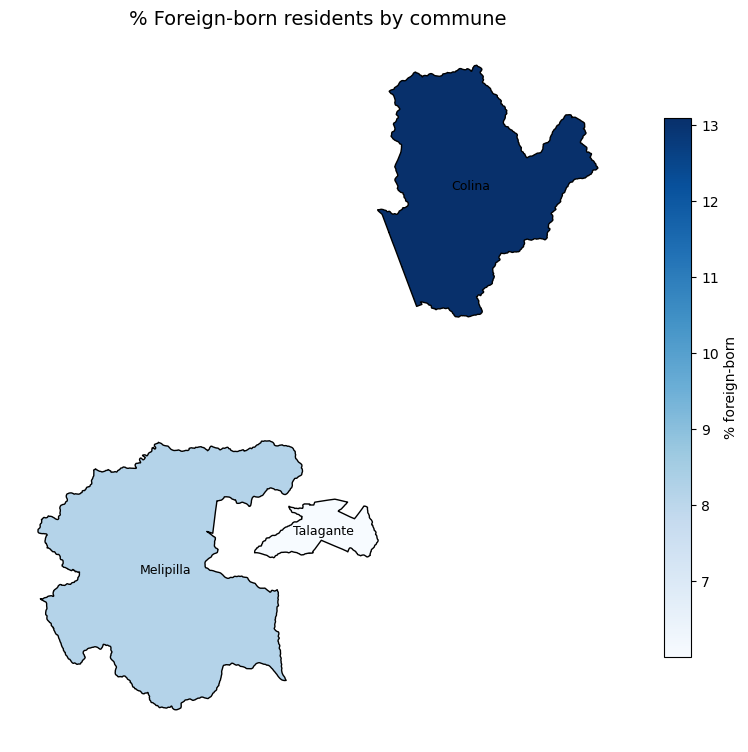

In [51]:
fig, ax = plt.subplots(figsize=(8, 8))

map_foreign_gdf.plot(
    column="pct_foreign_born",
    cmap="Blues",
    linewidth=1,
    edgecolor="black",
    legend=True,
    legend_kwds={"label": "% foreign-born", "shrink": 0.7},
    ax=ax
)

for _, row in map_foreign_gdf.iterrows():
    centroid = row.geometry.centroid
    ax.text(
        centroid.x,
        centroid.y,
        row["Comuna"],
        fontsize=9,
        ha="center",
        va="center"
    )

ax.set_title("% Foreign-born residents by commune", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.show()

Se construye un mapa coroplético que muestra el porcentaje de población nacida en el extranjero en cada comuna, usando distintos tonos para representar su magnitud. Se puede observar que Colina es la que más porcentaje de habitantes extranjeros tiene, seguido de Melipilla y Talagante.

## Part 4: Comuna-Level Summary Table (1 pt)


In [52]:
import os

# ============================================================
# PART 4 - Comuna-level summary table
# versión corregida
# ============================================================

# ------------------------------------------------------------
# 0) Base de trabajo
# ------------------------------------------------------------
summary_df = df.copy()

name_to_code = {
    "Colina": 13301,
    "Melipilla": 13501,
    "Talagante": 13601
}

code_to_name = {
    13301: "Colina",
    13501: "Melipilla",
    13601: "Talagante"
}

# Asegurar codigo_comuna y nombre_comuna
if "codigo_comuna" not in summary_df.columns:
    summary_df["codigo_comuna"] = summary_df["comuna"].replace(name_to_code)

summary_df["codigo_comuna"] = pd.to_numeric(summary_df["codigo_comuna"], errors="coerce")

if "nombre_comuna" not in summary_df.columns:
    summary_df["nombre_comuna"] = summary_df["codigo_comuna"].map(code_to_name)

# Quedarse solo con las 3 comunas
summary_df = summary_df[summary_df["codigo_comuna"].isin([13301, 13501, 13601])].copy()

# Base fija de comunas
comunas_base = pd.DataFrame({
    "codigo_comuna": [13301, 13501, 13601],
    "nombre_comuna": ["Colina", "Melipilla", "Talagante"]
}).set_index("codigo_comuna")

# ------------------------------------------------------------
# 1) pop_total
# ------------------------------------------------------------
pop_total = (
    summary_df.groupby("codigo_comuna")
    .size()
    .rename("pop_total")
)

# ------------------------------------------------------------
# 2) pop_chilean, pop_foreign, pct_foreign
# usando p25_lug_nacimiento_rec
# 1 = born in Chile
# 2 = born abroad
# ------------------------------------------------------------
birth_valid = summary_df[
    summary_df["p25_lug_nacimiento_rec"].isin([1, 2])
].copy()

birth_counts = (
    birth_valid.groupby(["codigo_comuna", "p25_lug_nacimiento_rec"])
    .size()
    .unstack(fill_value=0)
)

for col in [1, 2]:
    if col not in birth_counts.columns:
        birth_counts[col] = 0

birth_counts = birth_counts.rename(columns={
    1: "pop_chilean",
    2: "pop_foreign"
})

birth_counts["pct_foreign"] = (
    birth_counts["pop_foreign"] /
    (birth_counts["pop_chilean"] + birth_counts["pop_foreign"]).replace(0, np.nan)
) * 100

# ------------------------------------------------------------
# 3) median_age_chilean, median_age_foreign
# excluir edad = -99
# ------------------------------------------------------------
age_valid = summary_df[
    (summary_df["edad"] != -99) &
    (summary_df["p25_lug_nacimiento_rec"].isin([1, 2]))
].copy()

median_age = (
    age_valid.groupby(["codigo_comuna", "p25_lug_nacimiento_rec"])["edad"]
    .median()
    .unstack()
)

for col in [1, 2]:
    if col not in median_age.columns:
        median_age[col] = np.nan

median_age = median_age.rename(columns={
    1: "median_age_chilean",
    2: "median_age_foreign"
})

# ------------------------------------------------------------
# 4) mean_schooling_chilean, mean_schooling_foreign
# población 25+, excluir escolaridad = -99
# ------------------------------------------------------------
school_valid = summary_df[
    (summary_df["edad"] != -99) &
    (summary_df["edad"] >= 25) &
    (summary_df["escolaridad"] != -99) &
    (summary_df["p25_lug_nacimiento_rec"].isin([1, 2]))
].copy()

mean_school = (
    school_valid.groupby(["codigo_comuna", "p25_lug_nacimiento_rec"])["escolaridad"]
    .mean()
    .unstack()
)

for col in [1, 2]:
    if col not in mean_school.columns:
        mean_school[col] = np.nan

mean_school = mean_school.rename(columns={
    1: "mean_schooling_chilean",
    2: "mean_schooling_foreign"
})

# ------------------------------------------------------------
# 5) emp_rate_chilean, emp_rate_foreign
# CORREGIDO:
# población 15-64 con sit_fuerza_trabajo válido
# denominador = TODA la población válida 15-64
# numerador = ocupados (sit_fuerza_trabajo == 1)
# ------------------------------------------------------------
emp_valid = summary_df[
    (summary_df["edad"] != -99) &
    (summary_df["edad"] >= 15) &
    (summary_df["edad"] <= 64) &
    (summary_df["sit_fuerza_trabajo"] != -99) &
    (summary_df["p25_lug_nacimiento_rec"].isin([1, 2]))
].copy()

emp_valid["is_employed"] = (emp_valid["sit_fuerza_trabajo"] == 1).astype(int)

emp_rate = (
    emp_valid.groupby(["codigo_comuna", "p25_lug_nacimiento_rec"])["is_employed"]
    .mean()
    .mul(100)
    .unstack()
)

for col in [1, 2]:
    if col not in emp_rate.columns:
        emp_rate[col] = np.nan

emp_rate = emp_rate.rename(columns={
    1: "emp_rate_chilean",
    2: "emp_rate_foreign"
})

# ------------------------------------------------------------
# 6) dependency_ratio overall
# excluir edad = -99
# fórmula:
# (0-14 + 65+) / (15-64)
# ------------------------------------------------------------
dep_valid = summary_df[summary_df["edad"] != -99].copy()

dep_0_14 = dep_valid.groupby("codigo_comuna")["edad"].apply(lambda x: ((x >= 0) & (x <= 14)).sum())
dep_15_64 = dep_valid.groupby("codigo_comuna")["edad"].apply(lambda x: ((x >= 15) & (x <= 64)).sum())
dep_65_plus = dep_valid.groupby("codigo_comuna")["edad"].apply(lambda x: (x >= 65).sum())

dependency_ratio = (
    ((dep_0_14 + dep_65_plus) / dep_15_64.replace(0, np.nan))
    .rename("dependency_ratio")
)

# ------------------------------------------------------------
# 7) Unir todo
# ------------------------------------------------------------
summary = comunas_base.join(pop_total, how="left")
summary = summary.join(birth_counts[["pop_chilean", "pop_foreign", "pct_foreign"]], how="left")
summary = summary.join(median_age[["median_age_chilean", "median_age_foreign"]], how="left")
summary = summary.join(mean_school[["mean_schooling_chilean", "mean_schooling_foreign"]], how="left")
summary = summary.join(emp_rate[["emp_rate_chilean", "emp_rate_foreign"]], how="left")
summary = summary.join(dependency_ratio, how="left")

summary = summary.reset_index()

# ------------------------------------------------------------
# 8) Orden final de columnas
# ------------------------------------------------------------
summary = summary[
    [
        "codigo_comuna",
        "nombre_comuna",
        "pop_total",
        "pop_chilean",
        "pop_foreign",
        "pct_foreign",
        "median_age_chilean",
        "median_age_foreign",
        "mean_schooling_chilean",
        "mean_schooling_foreign",
        "emp_rate_chilean",
        "emp_rate_foreign",
        "dependency_ratio"
    ]
]

# ------------------------------------------------------------
# 9) Formato
# ------------------------------------------------------------
for col in ["pop_total", "pop_chilean", "pop_foreign"]:
    summary[col] = summary[col].fillna(0).astype(int)

round_cols = [
    "pct_foreign",
    "median_age_chilean",
    "median_age_foreign",
    "mean_schooling_chilean",
    "mean_schooling_foreign",
    "emp_rate_chilean",
    "emp_rate_foreign",
    "dependency_ratio"
]
summary[round_cols] = summary[round_cols].round(2)

# ------------------------------------------------------------
# 10) Guardar CSV
# ------------------------------------------------------------
summary.to_csv("summary_table_part4.csv", index=False, encoding="utf-8-sig")

summary

,codigo_comuna,nombre_comuna,pop_total,pop_chilean,pop_foreign,pct_foreign,median_age_chilean,median_age_foreign,mean_schooling_chilean,mean_schooling_foreign,emp_rate_chilean,emp_rate_foreign,dependency_ratio
0,13301,Colina,173293,149378,22498,13.09,33.0,35.0,12.61,12.78,59.95,70.00,0.46
1,13501,Melipilla,136325,124407,11069,8.17,37.0,30.0,11.07,11.26,58.93,74.38,0.50
2,13601,Talagante,76429,71322,4559,6.01,36.0,32.0,11.83,12.26,59.75,69.74,0.47


Se calcula y se muestra la información para comparar las comunas analizadas.